In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pydicom import dcmread
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import pydose_rt as PDRT

In [2]:
config = PDRT.MachineConfig(ct_array_shape=(100, 100, 100), resolution=(0.5, 0.5, 0.5), field_size=(40, 40), number_of_leaf_pairs=1, tpr_20_10=0.72, number_of_beams=1)
print(config)

preset=None minimum_leaf_opening=5.0 minimum_jaw_opening=5.0 maximum_leaf_tip_overlap=150.0 maximum_jaw_speed=22.5 maximum_leaf_speed=22.5 minimum_gantry_angle_speed=0.1 maximum_gantry_angle_speed=6.0 maximum_gantry_angle_speed_variation=0.75 minimum_dose_rate=50.0 maximum_dose_rate=600.0 mlc_leakage_amplitude=0.0 mlc_leakage_range_mm=30.0 source_size_mm=1.5 head_scatter_amplitude=0.0 head_scatter_range_mm=150.0 tongue_groove_reduction=0.0 tongue_groove_width_mm=1.0 tpr_20_10=0.72 mean_photon_energy_MeV=10.0 leaf_widths=None number_of_leaf_pairs=1


(167, 1, 1, 65, 65)


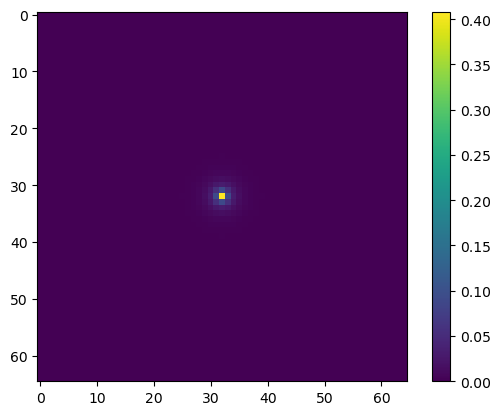

In [20]:
kernels = []

kernel_size = 65
resolution = (1.0, 1.0, 1.0)
tpr_20_10 = 0.72
pbm = PDRT.physics.PencilBeamModel(resolution=resolution, tpr_20_10=tpr_20_10, kernel_size=kernel_size)
rs = pbm.get_rs([kernel_size, kernel_size])
depths = np.arange(0.0, 50.0, 0.3)
for depth in depths:
    kernels.append(pbm.get_nested_kernels(np.array([[[depth]]])))

kernels = np.stack(kernels, 0)
print(kernels.shape)
plt.imshow(kernels[0, 0, 0, :, :])
plt.colorbar()
plt.show()

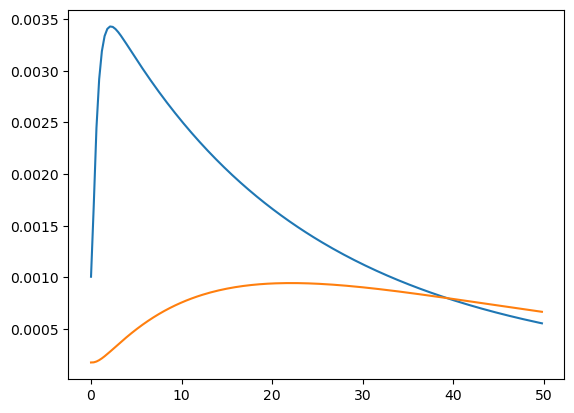

In [24]:
plt.plot(depths, pbm.depth_A_per_a(depths))
plt.plot(depths, pbm.depth_B_per_b(depths))

In [6]:
plt.figure(figsize=(10, 5))
# plt.subplot(121)
plt.plot(kernels[15, 25, :], label="Depth 15")
# plt.plot(kernels[120, 25, :], label="Depth 120")
# plt.imshow(np.log(kernels[15, :, :]), vmax=np.max(kernels))
# plt.subplot(122)

# plt.imshow(np.log(kernels[120, :, :]), vmax=np.max(kernels))

TypeError: list indices must be integers or slices, not tuple

<Figure size 1000x500 with 0 Axes>

In [ ]:
x_ct = np.expand_dims(np.zeros(config.ct_array_shape), 0)
y_mlc = np.zeros((1, 2, config.number_of_beams, config.number_of_leaf_pairs))
y_mlc[:, 0, :, :] = 0.5
y_mlc[:, 1, :, :] = 1.0
mus = 0.1 * np.ones((1, config.number_of_beams), dtype=np.float32)
dose_layer = AccumulateDose3DLayer(config, 15)
dose = dose_layer(x_ct, y_mlc, mus)

In [ ]:
slice_idx = 84
print(dose.shape)

plt.imshow(dose[0, :, 84, :], cmap='jet', vmin=np.min(dose), vmax=np.max(dose))
plt.axis('off')
plt.colorbar()
# plt.axis('off')
plt.show()

In [ ]:
path ="/home/bolo/Downloads/10x10-10MV/RD1.2.752.243.1.1.20240927183310596.8800.73001.dcm"
path_ct = "/home/bolo/Downloads/10x10-10MV/CT1.2.752.243.1.1.20210112110104939.5560.87015.dcm"
ds = dcmread(path)
ds_ref = ds.pixel_array
ds_ref = np.transpose(ds_ref, (1, 2, 0))
print(ds_ref.shape)

plt.imshow(ds_ref[:, 84, :], cmap='jet')
plt.axis('off')
plt.colorbar()
plt.show()

In [ ]:
slice_idx = 84
print(dose.shape)
print(ds_ref.shape)

dose = dose * np.max(ds_ref[34, ...]) / np.max(dose[0, 34, ...])
# dose = dose * np.max(ds_ref) / np.max(dose)
plt.subplot(131)
plt.imshow(dose[0, :, 84, :], cmap='jet')
plt.axis('off')
plt.subplot(132)
plt.imshow(ds_ref[:, 84, :], cmap='jet')
plt.axis('off')
plt.subplot(133)
plt.imshow((ds_ref[:, 84, :] - dose[0, :, 84, :]) / (ds_ref[:, 84, :] + 1e-10), cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.axis('off')
plt.show()

In [ ]:
air_gap = 1

print(config)

slice_idx = 84
depth_index = 92

x = np.linspace(0, config.ct_array_shape[0], config.ct_array_shape[0])

# Create the plot
plt.plot(x, dose[0, :, slice_idx, depth_index], label='TensorFlow', color='orange')
plt.plot(x, ds_ref[:, slice_idx, depth_index], label='Phantom', color='blue')
plt.legend()

# Set x-ticks from 0 to 128, but label them as 0 to 26
num_ticks = 10
new_xticks = np.linspace(0, config.ct_array_shape[0], num_ticks)  # 27 points from 0 to 128
new_xtick_labels = np.round(np.linspace(0, config.ct_array_shape[0]*config.resolution[0], num_ticks), 1)  # Corresponding labels from 0 to 26

# Apply the new ticks and labels
plt.xticks(new_xticks, new_xtick_labels)
plt.xlabel('[cm]')

# Show the plot
plt.show()

In [ ]:
print(config)

x = np.linspace(0, config.ct_array_shape[0], config.ct_array_shape[0])

# Create the plot
slices = np.linspace(5, config.ct_array_shape[0], 3, endpoint=False).astype(int)
line_styles = ['-', '--', ':']
for i in range(len(slices)):
  plt.plot(x, ds_ref[slices[i], :, slice_idx], label=f'Phantom (d={int(slices[i] * config.resolution[1])} cm)', color='blue', linestyle=line_styles[i])
  plt.plot(x, dose[0, slices[i], :, depth_index], label=f'Tensorflow (d={int(slices[i] * config.resolution[1])} cm)', color='orange', linestyle=line_styles[i])
plt.legend()

# Apply the new ticks and labels
plt.xticks(new_xticks, new_xtick_labels)
plt.xlabel('[cm]')

# Show the plot
plt.show()